<a href="https://colab.research.google.com/github/Gr1lledChee5e/RegressionAnalysis/blob/main/RestaurantRevenue_40features_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pregress

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.9 MB/s eta 0:00:00


In [ ]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as npx


# General
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vS2-Xs8DAd-7zJMLiunVfmSyDmCalO1tHxnOUPGNRUUhEMwEzyZ3wlm4r2TS6c17hSYvUZ3o1t0tJjO/pub?gid=1603445953&single=true&output=csv')

# Observe Data

In [ ]:
df.head()

,Revenue,City,Brand,Type,OpenDate,PC1,PC2,PC3,PC4,PC5,...,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40
0,1093504.470,Miami,Chicken Shack,Full,2002-02-20,-1.017050,1.099437,0.175054,0.019721,-0.103649,...,-0.882691,0.916538,-2.693251,1.248734,-0.993489,0.322026,-2.416955,-0.313367,-0.363301,1.686302
1,1071089.537,Miami,Jack's Burgers,Full,2018-04-21,-1.574953,-0.357271,0.501697,1.284168,-1.242511,...,-1.515803,-0.394199,-0.273249,1.383726,0.606348,1.242120,3.054028,0.451160,-0.461476,2.308292
2,1121171.186,Fort Lauderdale,Pizza Mania,Delivery,2021-04-13,1.925025,-0.321213,0.222111,-1.034896,2.577896,...,-1.131869,-1.183637,-0.548637,-1.486104,1.776911,0.942981,-2.191019,-0.788192,-0.755879,-0.714948
3,1038822.169,Other,Jack's Burgers,Full,2017-12-27,-0.810896,0.550817,1.003248,2.395811,-0.786508,...,0.079864,0.171095,-0.153748,-0.660055,1.234600,-1.853840,-0.375997,-0.083330,-0.896011,1.653365
4,1000887.052,Miami,Pizza Mania,Delivery,2021-06-12,0.633963,-0.682535,-0.332347,-0.091216,1.077277,...,-0.544425,2.095725,-0.464862,-2.054798,3.104696,1.619110,1.004244,-0.993537,-1.101476,0.429827


In [ ]:
df.describe()

,Revenue,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40
count,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,...,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,1.036714e+06,-1.559840e-11,-3.799899e-11,1.860000e-11,2.701140e-10,-5.303790e-11,-3.600992e-12,-8.734494e-12,-7.144983e-12,-5.795800e-11,...,-1.675700e-11,6.258094e-12,-2.552310e-11,3.001900e-11,1.938701e-11,-1.962320e-11,-2.073899e-11,-4.680679e-10,2.070599e-11,4.953971e-11
std,6.169140e+04,1.435638e+00,1.428518e+00,1.422180e+00,1.409006e+00,1.391205e+00,1.387415e+00,1.372107e+00,1.368174e+00,1.367129e+00,...,1.234721e+00,1.230057e+00,1.225977e+00,1.225620e+00,1.218542e+00,1.217614e+00,1.212887e+00,1.206462e+00,1.199427e+00,1.196096e+00
min,8.031449e+05,-5.232789e+00,-4.002654e+00,-4.814163e+00,-4.250107e+00,-4.239178e+00,-3.997011e+00,-4.057488e+00,-3.994712e+00,-3.550778e+00,...,-4.812363e+00,-3.641560e+00,-3.776906e+00,-3.570580e+00,-4.072958e+00,-3.329979e+00,-3.199616e+00,-3.826645e+00,-3.465486e+00,-3.726839e+00
25%,9.971095e+05,-1.003633e+00,-9.385868e-01,-9.592316e-01,-9.373985e-01,-9.158626e-01,-8.986212e-01,-9.979686e-01,-9.118149e-01,-8.679408e-01,...,-8.589728e-01,-8.621160e-01,-7.814368e-01,-8.119395e-01,-8.264212e-01,-8.375545e-01,-8.379106e-01,-8.238536e-01,-8.043545e-01,-8.227388e-01
50%,1.035560e+06,1.373307e-04,-5.451205e-03,8.291628e-03,-4.390752e-02,3.399776e-02,2.354414e-02,4.933359e-02,-5.788860e-02,-3.330187e-02,...,5.865278e-02,6.435945e-02,-1.103107e-02,3.903671e-02,-4.472348e-02,-1.573966e-02,-4.381620e-02,-2.942445e-02,-9.677958e-03,-2.508208e-03
75%,1.076060e+06,9.863844e-01,9.536184e-01,9.270548e-01,9.725856e-01,8.720922e-01,9.345359e-01,9.146495e-01,8.788619e-01,9.337650e-01,...,8.380394e-01,8.467358e-01,8.137869e-01,8.453518e-01,8.401005e-01,7.666183e-01,8.298549e-01,7.880377e-01,7.625016e-01,8.175026e-01
max,1.253742e+06,4.220941e+00,4.264667e+00,4.582753e+00,4.002144e+00,5.271936e+00,3.959667e+00,4.645120e+00,4.933844e+00,4.744265e+00,...,3.317963e+00,4.129575e+00,4.009382e+00,3.965576e+00,3.793729e+00,3.909100e+00,3.281485e+00,4.066908e+00,4.044186e+00,4.658774e+00


In [ ]:
df.Brand.value_counts()

,count
Brand,
Jack's Burgers,384
Taco Hut,310
Chicken Shack,202
Pizza Mania,104


In [ ]:
df.Type.value_counts()

,count
Type,
Full,765
Express,97
Delivery,80
Food Court,58


# Split and Fit a Lasso Model

In [ ]:
y = df['Revenue']
X = df.drop(['Revenue','City','Brand', 'Type', 'OpenDate'], axis=1)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import root_mean_squared_error
lasso = Lasso(alpha=0.1)
lasso.fit(x_train, y_train)
y_pred = lasso.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

54791.53020621524


# Hyperparameter Tune Your Lasso Model

In [ ]:
np.linspace(0.001, 1, 100)

array([0.001     , 0.01109091, 0.02118182, 0.03127273, 0.04136364,
       0.05145455, 0.06154545, 0.07163636, 0.08172727, 0.09181818,
       0.10190909, 0.112     , 0.12209091, 0.13218182, 0.14227273,
       0.15236364, 0.16245455, 0.17254545, 0.18263636, 0.19272727,
       0.20281818, 0.21290909, 0.223     , 0.23309091, 0.24318182,
       0.25327273, 0.26336364, 0.27345455, 0.28354545, 0.29363636,
       0.30372727, 0.31381818, 0.32390909, 0.334     , 0.34409091,
       0.35418182, 0.36427273, 0.37436364, 0.38445455, 0.39454545,
       0.40463636, 0.41472727, 0.42481818, 0.43490909, 0.445     ,
       0.45509091, 0.46518182, 0.47527273, 0.48536364, 0.49545455,
       0.50554545, 0.51563636, 0.52572727, 0.53581818, 0.54590909,
       0.556     , 0.56609091, 0.57618182, 0.58627273, 0.59636364,
       0.60645455, 0.61654545, 0.62663636, 0.63672727, 0.64681818,
       0.65690909, 0.667     , 0.67709091, 0.68718182, 0.69727273,
       0.70736364, 0.71745455, 0.72754545, 0.73763636, 0.74772

In [ ]:
alphas = np.linspace(0.001, 1, 100)
training_errors = []
test_errors = []

for alpha in alphas:
  lasso = Lasso(alpha=alpha)
  lasso.fit(x_train, y_train)
  y_pred = lasso.predict(x_test)
  y_pred_train = lasso.predict(x_train)
  training_errors.append(root_mean_squared_error(y_train, y_pred_train))
  test_errors.append(root_mean_squared_error(y_test, y_pred))

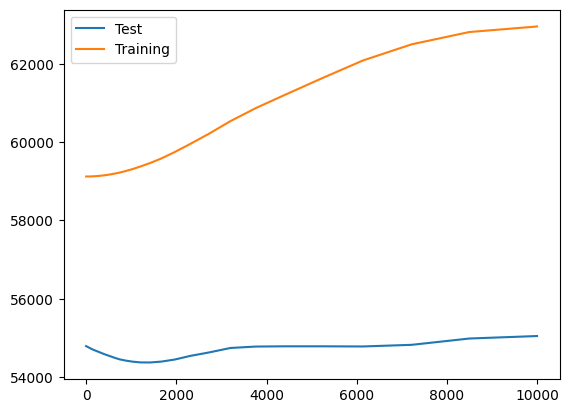

In [ ]:
alphas = np.logspace(-3, 4, 100)
training_errors = []
test_errors = []
for alpha in alphas:
  lasso = Lasso(alpha=alpha)
  lasso.fit(x_train, y_train)
  y_pred = lasso.predict(x_test)
  y_pred_train = lasso.predict(x_train)
  training_errors.append(root_mean_squared_error(y_train, y_pred_train))
  test_errors.append(root_mean_squared_error(y_test, y_pred))

plt.plot(alphas, test_errors, label='Test')
plt.plot(alphas, training_errors, label='Training')
plt.legend()
plt.show()

# Specify the Best Alpha

In [ ]:
best_alpha_index = np.argmin(test_errors)
best_alpha = alphas[best_alpha_index]
print(f"The best alpha value is: {best_alpha}")

The best alpha value is: 1417.4741629268049


In [ ]:
bestlasso = Lasso(alpha=best_alpha)
bestlasso.fit(x_train, y_train)

Lasso(alpha=np.float64(1417.4741629268049))

# Verify the Test Error

In [ ]:
y_pred = bestlasso.predict(x_test)
test_error = root_mean_squared_error(y_test, y_pred)
print(f"The test error is: {test_error}")

The test error is: 54373.84401853493


In [ ]:
test_error = test_errors[best_alpha_index]
print(f"The test error is: {test_error}")

The test error is: 54373.84401853493


# Print Model Coefficients

In [ ]:
bestlasso.coef_


array([ 1367.70980789,   811.33064457,  2285.59824938, -1031.40323537,
         790.11771921,    -0.        ,  5838.19603337, -2491.41092593,
       -1301.18900257, -4138.46295743,  2601.57097108,    -0.        ,
        3558.39957964,     0.        ,  2097.29765618,   955.29826727,
         279.37942351,  1300.71765296, -2152.91169997,   717.44349856,
        -561.62451562, -1052.29332389,    -0.        , -4049.53605363,
           0.        ,     0.        ,   448.77178538, -1649.28456428,
        1765.92924931,    -0.        ,  1082.435739  ,    -0.        ,
       -1280.58403311, -3796.88463253,     0.        ,  3165.95748276,
        -466.42901026,  1323.32513087, -3540.51271044,   549.0938587 ])

# Create a Variable Importance Plot

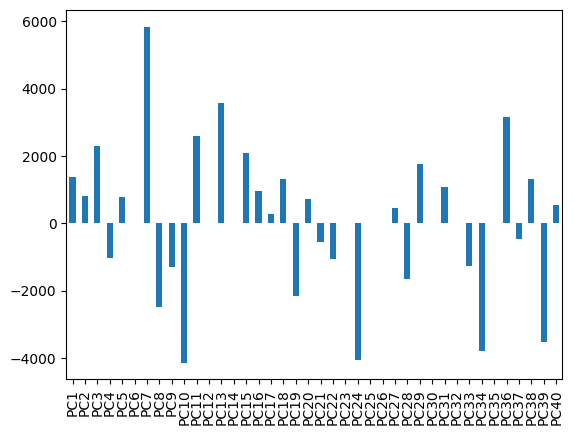

In [ ]:
variable_importance = pd.Series(bestlasso.coef_, index=X.columns)
variable_importance.plot(kind='bar')
plt.show()

# Use Cross Validation Error and compare with Test Error

In [ ]:
cross_val_scores = cross_val_score(lasso, X, y, cv=5)
print(f"The cross validation scores are: {cross_val_scores}")

The cross validation scores are: [ 0.0006313   0.00152721  0.00324028  0.0035398  -0.00581688]


# Find the Best CV Alpha and Fit a Model

In [ ]:
best_alpha_index = np.argmin(cross_val_scores)
best_alpha = alphas[best_alpha_index]
print(f"The best alpha value is: {best_alpha}")
modelfit = Lasso(alpha=best_alpha)
modelfit.fit(X, y)

The best alpha value is: 0.0019179102616724887


Lasso(alpha=np.float64(0.0019179102616724887))

# Check the Test Error

In [ ]:
test_error = root_mean_squared_error(y_test, modelfit.predict(x_test))
print(f"The test error is: {test_error}")

The test error is: 52919.802396847066


# Fit a Variable Importance Plot

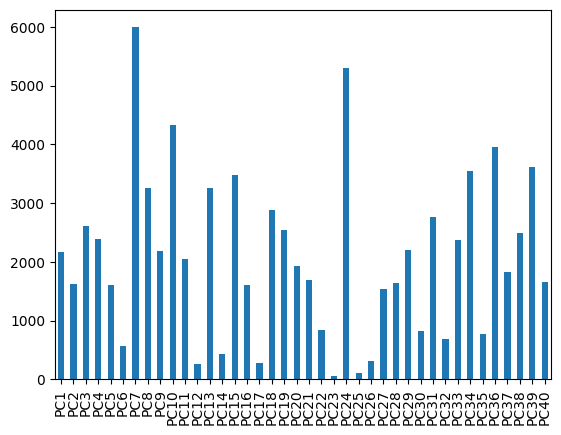

In [ ]:
abs_coef = np.abs(modelfit.coef_)
variable_importance = pd.Series(abs_coef, index=X.columns)
variable_importance.plot(kind='bar')
plt.show()

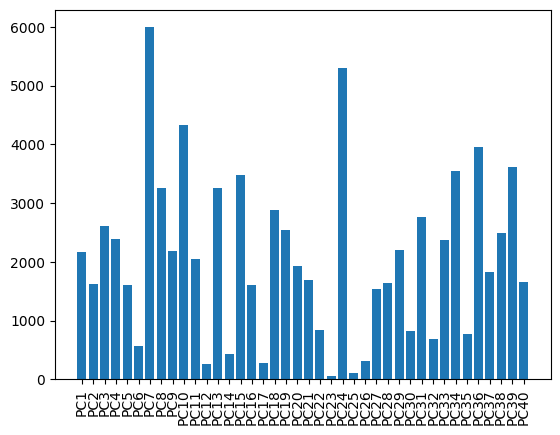

In [ ]:
abes_coef = np.abs(bestlasso.coef_)
plt.bar(X.columns, abs_coef)
plt.xticks(rotation=90)
plt.show()

# Fit a Ridge Model and Hyperparameter Tune Alpha using Cross-Validation

In [ ]:
ridgemodel = Ridge(alpha=0.1)
ridgemodel.fit(x_train, y_train)

Ridge(alpha=0.1)

In [ ]:
ridge_cv_errors = []
for alpha_val in alphas:
  ridge = Ridge(alpha=alpha_val)
  scores = cross_val_score(ridge, X, y, cv=5, scoring='neg_root_mean_squared_error')
  ridge_cv_errors.append(-np.mean(scores))
print(f"The cross validation RMSE for Ridge across alphas are: {ridge_cv_errors}")

The cross validation RMSE for Ridge across alphas are: [np.float64(60586.149735871666), np.float64(60586.12558980548), np.float64(60586.10144464103), np.float64(60586.07730037828), np.float64(60586.05315701722), np.float64(60586.029014557775), np.float64(60586.00487299993), np.float64(60585.98073234367), np.float64(60585.95659258894), np.float64(60585.93245373571), np.float64(60585.908315783934), np.float64(60585.884178733606), np.float64(60585.86004258467), np.float64(60585.835907337096), np.float64(60585.81177299084), np.float64(60585.787639545895), np.float64(60585.76350700219), np.float64(60585.73937535973), np.float64(60585.71524461844), np.float64(60585.691114778325), np.float64(60585.66698583933), np.float64(60585.6428578014), np.float64(60585.61873066456), np.float64(60585.59460442872), np.float64(60585.57047909386), np.float64(60585.546354659964), np.float64(60585.52223112698), np.float64(60585.498108494874), np.float64(60585.47398676362), np.float64(60585.44986593318), np.flo

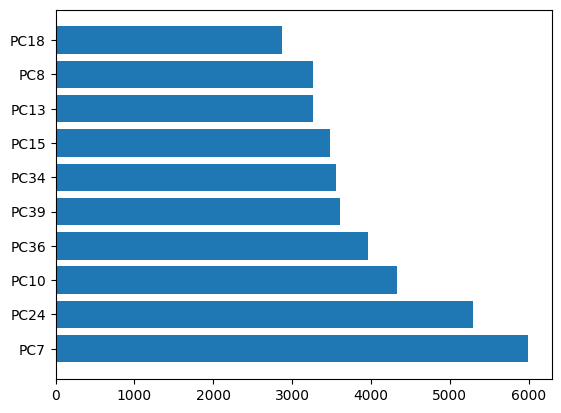

In [ ]:
feature_names = X.columns
sorted_idx = np.argsort(abs_coef)[::-1]
top_10_indices = sorted_idx[:10]
plt.barh(range(10), abs_coef[top_10_indices])
plt.yticks(range(10), np.array(feature_names)[top_10_indices])
plt.show()



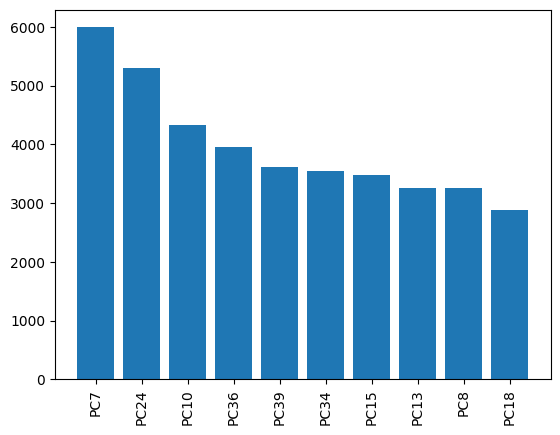

In [ ]:
feature_names = X.columns
sorted_idx = np.argsort(abs_coef)[::-1]
top_10_indices = sorted_idx[:10]
plt.bar(range(10), abs_coef[top_10_indices])
plt.xticks(range(10), np.array(feature_names)[top_10_indices], rotation=90)
plt.show()

# Plot the CV Error and Test Error

The cross validation error is: 60584.05239788904
The test error is: 54791.29318304475


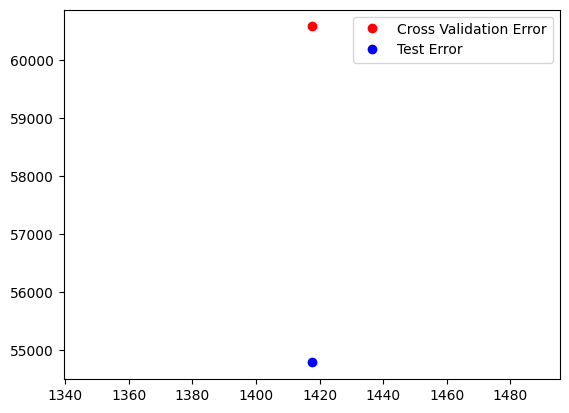

In [ ]:
cv_error = ridge_cv_errors[best_alpha_index]
print(f"The cross validation error is: {cv_error}")

test_error = root_mean_squared_error(y_test, ridgemodel.predict(x_test))
print(f"The test error is: {test_error}")


plt.plot(best_alpha, cv_error, 'ro', label='Cross Validation Error')
plt.plot(best_alpha, test_error, 'bo', label='Test Error')
plt.legend()
plt.show()

# Create a Variable Importance Plot

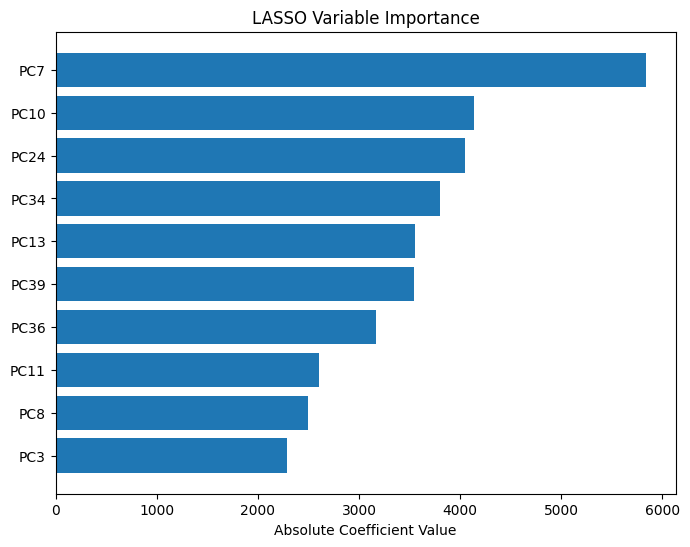

In [ ]:
# Fit final model using best alpha
lasso_best = Lasso(alpha=best_alpha).fit(x_train, y_train)

# Extract importance
coef = lasso_best.coef_
importance = np.abs(coef)


idx = np.argsort(importance)[::-1]
top_10_indices = idx[:10]
sorted_importance = importance[top_10_indices]
sorted_features = np.array(x_train.columns)[top_10_indices]

plt.figure(figsize=(8,6))
plt.barh(sorted_features, sorted_importance)
plt.gca().invert_yaxis()
plt.xlabel('Absolute Coefficient Value')
plt.title('LASSO Variable Importance')
plt.show()


## Notebook Summary for GitHub

This notebook demonstrates the process of building and evaluating regularized linear regression models (Lasso and Ridge) for predicting restaurant revenue.

### Key Steps:
1.  **Data Loading and Initial Observation**: Loaded restaurant revenue data and performed initial data exploration using `df.head()`, `df.describe()`, `value_counts()` on categorical features.
2.  **Data Preparation**: Separated the target variable ('Revenue') from features and split the data into training and testing sets.
3.  **Lasso Regression**: Implemented and evaluated a Lasso regression model. Hyperparameter tuning for the `alpha` parameter was performed using a range of values and `root_mean_squared_error` to identify the best `alpha` based on test error.
4.  **Lasso Variable Importance**: Visualized the coefficients of the best Lasso model to understand feature importance.
5.  **Cross-Validation for Lasso**: Utilized cross-validation to find an optimal `alpha` for the Lasso model and compared the cross-validation error with the test error.
6.  **Ridge Regression**: Implemented a Ridge regression model and hyperparameter tuned its `alpha` parameter using cross-validation (`neg_root_mean_squared_error`).
7.  **Comparison and Evaluation**: Compared the cross-validation and test errors for both Lasso and Ridge models, and visualized the top 10 most important features from the Lasso model.